# Task 4 - Channel effectiveness, measured

Data: `channel_trials.csv` (5 channels x 6 ratios = 30 trials), `iris.csv`.

A small-scale version of Cleveland & McGill's experiment: the same pair of numbers is encoded in five ways and the reader guesses the ratio.

In [1]:
%matplotlib inline

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

GREY = "#bbbbbb"
GREY_DARK = "#777777"
ACCENT = "#ee6677"
BLUE = "#4477aa"
INK = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": GREY_DARK,
    "xtick.color": GREY_DARK,
    "ytick.color": GREY_DARK,
})


def declutter(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", dpi=300, bbox_inches="tight")

from matplotlib.patches import Rectangle


# --- showing a stimulus in VS Code -------------------------------------
# VS Code delivers cell output and input() prompts on two separate
# channels, so without a pause the prompt box can open while the figure is
# still being painted - the reader would answer the previous picture.
# SETTLE is the head start the picture gets. The response timer starts
# after show_stimulus() returns, so this never lands inside rt_ms.
SETTLE = 0.35


def show_stimulus(fig, settle=SETTLE):
    clear_output(wait=True)   # old figure goes only when the new one lands
    display(fig)
    plt.close(fig)
    sys.stdout.flush()
    time.sleep(settle)

In [2]:
trials = pd.read_csv(DATA / "channel_trials.csv")
trials.pivot(index="true_ratio", columns="channel", values="trial")

channel,angle,area,colour,length,position
true_ratio,,,,,
0.15,13,19,25,7,1
0.25,14,20,26,8,2
0.40,15,21,27,9,3
0.55,16,22,28,10,4
0.70,17,23,29,11,5
0.85,18,24,30,12,6


## 1. Five encoders

Every function gets the two values in the order they should appear (left, right) and draws them with one channel only. No ticks, numbers or axis labels, just "A" and "B" so the reader can say which is which.

For `area` I pass `s` proportional to the value. In `ax.scatter`, `s` is the marker **area** in points², so this is the correct area encoding. If I'd used `value**2`, I'd have made the area lie (the bigger circle would look far bigger than it really is).

For `colour` I use a grey lightness ramp (darker = more), because grey has an obvious order. A rainbow doesn't.

In [3]:
def _blank(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


def enc_position(ax, a, b):
    ax.plot([0, 0], [0, 100], color=GREY_DARK, linewidth=1)
    ax.scatter([1, 2], [a, b], s=90, color=INK, zorder=3)
    ax.set_xlim(-0.5, 2.8)
    ax.set_ylim(-4, 104)
    for x, lab in [(1, "A"), (2, "B")]:
        ax.text(x, -10, lab, ha="center", va="top")


def enc_length(ax, a, b):
    ax.bar([1, 2], [a, b], width=0.55, color=GREY_DARK)
    ax.plot([0.5, 2.5], [0, 0], color=INK, linewidth=1)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylim(0, 104)
    for x, lab in [(1, "A"), (2, "B")]:
        ax.text(x, -4, lab, ha="center", va="top")


def enc_angle(ax, a, b):
    ax.pie([a, b], colors=[GREY, GREY_DARK], labels=["A", "B"], startangle=90,
           counterclock=False, wedgeprops={"edgecolor": "white", "linewidth": 2})


def enc_area(ax, a, b):
    ax.scatter([1, 2], [0, 0], s=[a * 60, b * 60], color=GREY_DARK)
    ax.set_xlim(0.3, 2.7)
    ax.set_ylim(-1, 1)
    for x, lab in [(1, "A"), (2, "B")]:
        ax.text(x, -0.85, lab, ha="center")


def enc_colour(ax, a, b):
    for x, v, lab in [(0.2, a, "A"), (1.4, b, "B")]:
        ax.add_patch(Rectangle((x, 0.2), 1, 1, color=plt.cm.Greys(0.08 + 0.87 * v / 100)))
        ax.text(x + 0.5, 0.05, lab, ha="center", va="top")
    ax.set_xlim(0, 2.6)
    ax.set_ylim(-0.2, 1.4)
    ax.set_aspect("equal")


ENCODERS = {"position": enc_position, "length": enc_length, "angle": enc_angle,
            "area": enc_area, "colour": enc_colour}


def draw_channel_trial(row, ax, swap=False):
    a, b = row["value_large"], row["value_small"]
    if swap:
        a, b = b, a
    ENCODERS[row["channel"]](ax, a, b)
    _blank(ax)

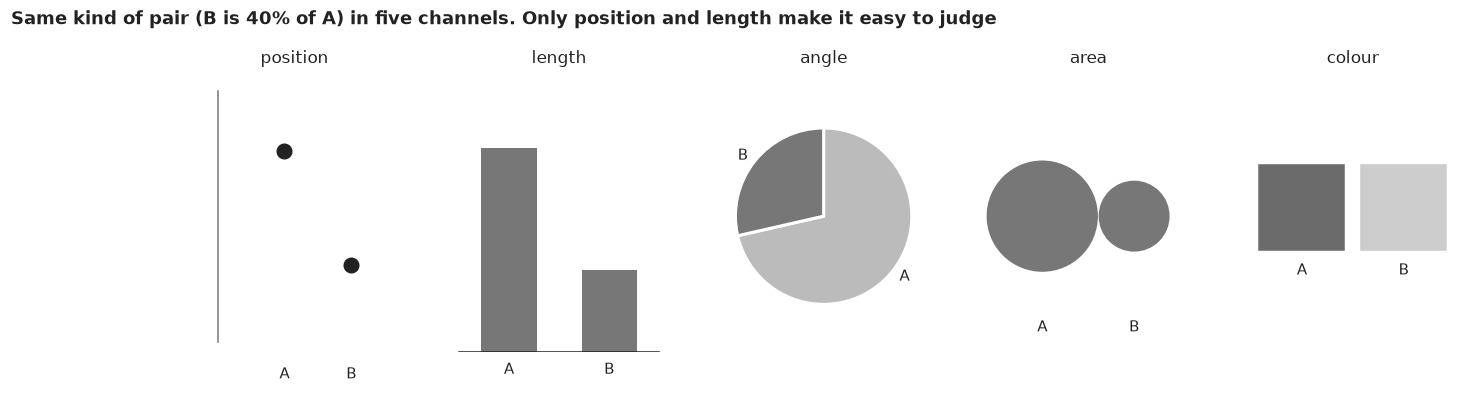

In [4]:
demo = trials[trials["true_ratio"] == 0.40]
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, (_, row) in zip(axes, demo.iterrows()):
    draw_channel_trial(row, ax)
    box = ax.get_position()
    fig.text(box.x0 + box.width / 2, 0.93, row["channel"], ha="center", fontsize=11)
fig.suptitle("Same kind of pair (B is 40% of A) in five channels. Only position and length make it easy to judge",
             x=0.02, ha="left", fontweight="bold", y=1.08)
save(fig, "task4_five_channels")
plt.show()

Don't show this figure to the reader before the test (the title gives away a ratio).

## 2. Running the 30 trials on a real person

The trial order is shuffled, and which side holds the bigger value is random too, so the reader can't pick up a pattern. Before starting, tell them: "for each picture, the smaller one is what percent of the larger? For the squares, darker = more." Don't tell them the true answers until the end.

Set `RUN_EXPERIMENT = True` only when the reader is ready, then set it back to `False`.

In [5]:
def run_channel_experiment(trials, reader, seed=3):
    rng = np.random.default_rng(seed)
    order = trials.sample(frac=1, random_state=int(rng.integers(1e6)))
    estimates = {}
    reprompted = {}
    n = len(order)
    # Instructions printed rather than passed to input(), which VS Code truncates.
    clear_output(wait=True)
    print(f"{reader}: for each picture, what % of the bigger one is the smaller one?")
    print("Squares: darker = more.")
    input("Enter to start... ")
    for k, (_, row) in enumerate(order.iterrows(), start=1):
        fig, ax = plt.subplots(figsize=(4.5, 3.6))
        draw_channel_trial(row, ax, swap=bool(rng.random() < 0.5))
        show_stimulus(fig)
        asked_again = False
        while True:
            ans = input(f"[{k}/{n}] smaller is what % of larger? ").strip().replace("%", "")
            try:
                estimates[row["trial"]] = float(ans)
                break
            except ValueError:
                asked_again = True
                print("type a number")
        reprompted[row["trial"]] = asked_again
    clear_output(wait=True)
    out = trials.copy()
    out["reader_estimate"] = out["trial"].map(estimates)
    out["reprompted"] = out["trial"].map(reprompted)
    out["absolute_error"] = (out["reader_estimate"] / 100 - out["true_ratio"]).abs()
    out["reader"] = reader
    return out

In [6]:
RUN_EXPERIMENT = False
READER = "Sami (self-test)"
RESULTS_FILE = Path("channel_results.csv")

if RUN_EXPERIMENT:
    if READER.startswith("write the reader"):
        raise ValueError("Set READER to your reader's first name before running.")
    results = run_channel_experiment(trials, READER)
    results.to_csv(RESULTS_FILE, index=False)
elif RESULTS_FILE.exists():
    results = pd.read_csv(RESULTS_FILE)
else:
    results = None
    print("channel_results.csv not found yet. Set RUN_EXPERIMENT = False and run this cell with your reader.")

results

,trial,channel,true_ratio,value_large,value_small,reader_estimate,absolute_error,reprompted,reader
0,1,position,0.15,76,11.40,25.0,0.10,False,Sami (self-test)
1,2,position,0.25,59,14.75,27.0,0.02,False,Sami (self-test)
2,3,position,0.40,76,30.40,20.0,0.20,False,Sami (self-test)
3,4,position,0.55,68,37.40,26.0,0.29,False,Sami (self-test)
4,5,position,0.70,61,42.70,7.0,0.63,False,Sami (self-test)
5,6,position,0.85,64,54.40,13.0,0.72,False,Sami (self-test)
6,7,length,0.15,70,10.50,14.0,0.01,False,Sami (self-test)
7,8,length,0.25,86,21.50,12.0,0.13,False,Sami (self-test)
8,9,length,0.40,78,31.20,8.0,0.32,False,Sami (self-test)
9,10,length,0.55,48,26.40,4.0,0.51,False,Sami (self-test)


**Reader:** _(name)_ - **notes:** _(anything they said, e.g. "the squares were pure guessing")_

## 3-4. Error per channel and the ranking

`absolute_error = |estimate/100 - true_ratio|`, so 0.10 means 10 percentage points off.

In [7]:
PUBLISHED = ["position", "length", "angle", "area", "volume", "colour"]

if results is None:
    print("No results yet - run the experiment first.")
else:
    err = (results.groupby("channel")["absolute_error"]
           .agg(mean="mean", sd="std", n="size")
           .sort_values("mean"))
    err["se"] = err["sd"] / np.sqrt(err["n"])
    err["my rank"] = range(1, len(err) + 1)
    err["published rank (of the 5 tested)"] = [ [p for p in PUBLISHED if p != "volume"].index(c) + 1 for c in err.index]
    if "reprompted" in results.columns:
        print(f"re-prompted trials (kept in): {int(results['reprompted'].sum())}")
    display(err.round(3))

re-prompted trials (kept in): 0


,mean,sd,n,se,my rank,published rank (of the 5 tested)
channel,,,,,,
colour,0.327,0.239,6,0.098,1,5
position,0.327,0.286,6,0.117,2,1
length,0.342,0.230,6,0.094,3,2
area,0.360,0.275,6,0.112,4,4
angle,0.363,0.270,6,0.110,5,3


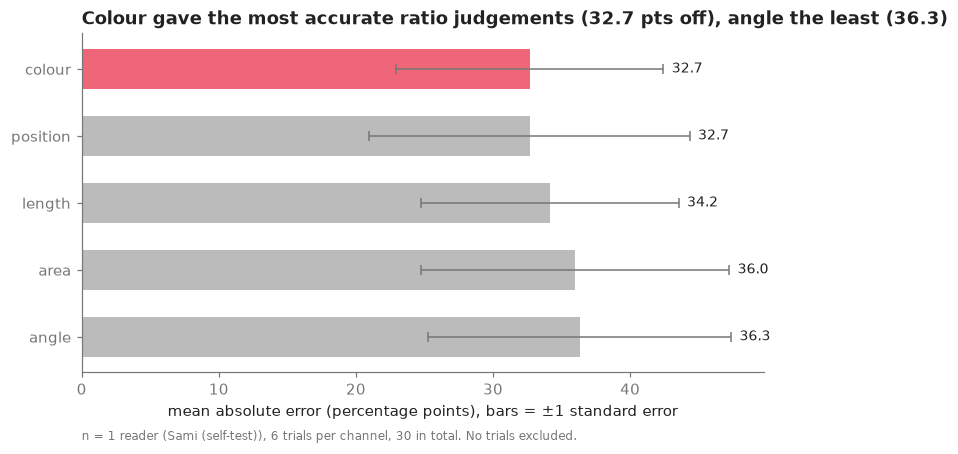

In [8]:
if results is not None:
    best = err.index[0]
    worst = err.index[-1]
    fig, ax = plt.subplots(figsize=(8, 4))
    y = np.arange(len(err))[::-1]
    ax.barh(y, err["mean"] * 100, xerr=err["se"] * 100, height=0.6,
            color=[ACCENT if c == best else GREY for c in err.index],
            error_kw={"ecolor": GREY_DARK, "capsize": 3, "linewidth": 1})
    ax.set_yticks(y)
    ax.set_yticklabels(err.index)
    for yi, (c, r) in zip(y, err.iterrows()):
        ax.text(r["mean"] * 100 + r["se"] * 100 + 0.6, yi, f"{r['mean'] * 100:.1f}", va="center", fontsize=9)
    ax.set_xlim(0, None)
    ax.set_xlabel("mean absolute error (percentage points), bars = ±1 standard error")
    ax.set_title(f"{best.capitalize()} gave the most accurate ratio judgements "
                 f"({err.loc[best, 'mean'] * 100:.1f} pts off), {worst} the least ({err.loc[worst, 'mean'] * 100:.1f})")
    declutter(ax)
    ax.text(0, -0.2, f"n = 1 reader ({READER}), 6 trials per channel, 30 in total. No trials excluded.",
            transform=ax.transAxes, fontsize=8, color=GREY_DARK)
    save(fig, "task4_channel_ranking")
    plt.show()

Sorted bars, zero baseline, error as length along a common axis (position/length, the top two channels). Only the most accurate channel is coloured. Each channel is named directly on the axis so there's no legend.

**Comparison with position > length > angle > area > (volume) > colour:** my order came out colour > position > length > area > angle.

| channel | mean error (pts) | 1 SE | my rank | published rank |
|---|---|---|---|---|
| colour | 32.7 | 9.8 | 1 | 5 |
| position | 32.7 | 11.7 | 2 | 1 |
| length | 34.2 | 9.4 | 3 | 2 |
| area | 36.0 | 11.2 | 4 | 4 |
| angle | 36.3 | 11.0 | 5 | 3 |

The order does not match the published one. The more honest point is that my data decides no order at all. The whole spread from best to worst is 3.6 percentage points, while every channel's standard error is 9 to 12 points, so each adjacent pair overlaps well inside one standard error. Colour and position are tied to one decimal place.

There is a bigger problem than the order. My estimates do not track the stimuli. The correlation between what I typed and the true ratio is -0.10, which is no relationship. Every answer I gave was between 2 and 30, while the true ratios ran from 15 to 85, so my error grows with the true value: about 1 to 15 points when the answer was near 15, and 57 to 80 points when it was near 85. That is the pattern you get when the answers are not responding to the picture.

I cannot separate the reasons from this run. I was my own reader, I built the stimuli, there are only 6 trials per channel, and I may have been answering something other than the ratio of smaller to larger. Whatever the cause, this run cannot support a claim about channel effectiveness, and the ranking above should not be read as one. It would need redoing, with the question restated and checked before the first trial, before it could be compared against the published order.

Volume wasn't tested, the brief only has five channels.

## 5. Applying it to `iris.csv`

Same message twice: setosa petals are much shorter than the other two species. Version A puts `petal_length` on position. Version B puts it on colour lightness only.

In [9]:
iris = pd.read_csv(DATA / "iris.csv")
means = iris.groupby("species")["petal_length"].mean()
means

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64

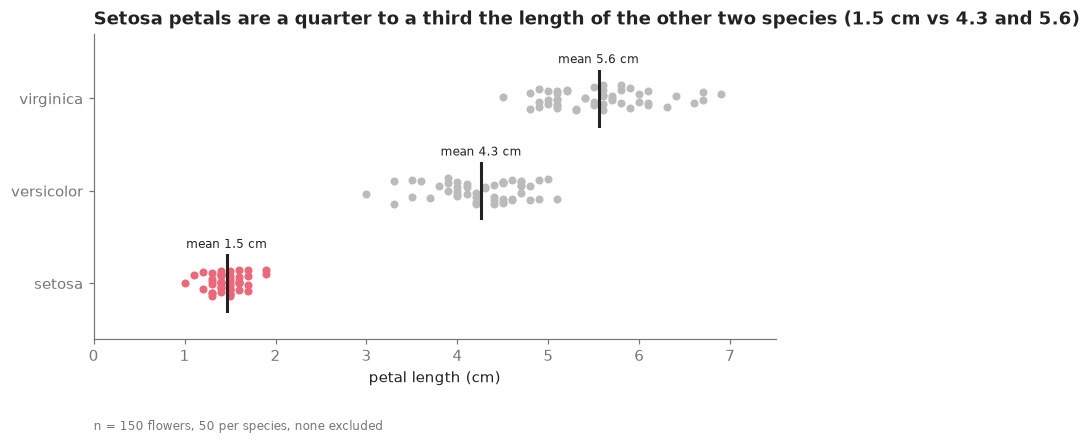

In [10]:
species = ["setosa", "versicolor", "virginica"]
rng = np.random.default_rng(1)

fig, ax = plt.subplots(figsize=(8, 3.6))
for i, sp in enumerate(species):
    v = iris.loc[iris["species"] == sp, "petal_length"]
    ax.scatter(v, np.full(len(v), i) + rng.uniform(-0.15, 0.15, len(v)), s=18,
               color=ACCENT if sp == "setosa" else GREY)
    ax.plot([means[sp]] * 2, [i - 0.3, i + 0.3], color=INK, linewidth=2)
    ax.text(means[sp], i + 0.38, f"mean {means[sp]:.1f} cm", ha="center", fontsize=8)
ax.set_yticks(range(3))
ax.set_yticklabels(species)
ax.set_ylim(-0.6, 2.7)
ax.set_xlim(0, 7.5)
ax.set_xlabel("petal length (cm)")
ax.set_title(f"Setosa petals are a quarter to a third the length of the other two species "
             f"({means['setosa']:.1f} cm vs {means['versicolor']:.1f} and {means['virginica']:.1f})")
declutter(ax)
ax.text(0, -0.3, "n = 150 flowers, 50 per species, none excluded", transform=ax.transAxes,
        fontsize=8, color=GREY_DARK)
save(fig, "task4_iris_position")
plt.show()

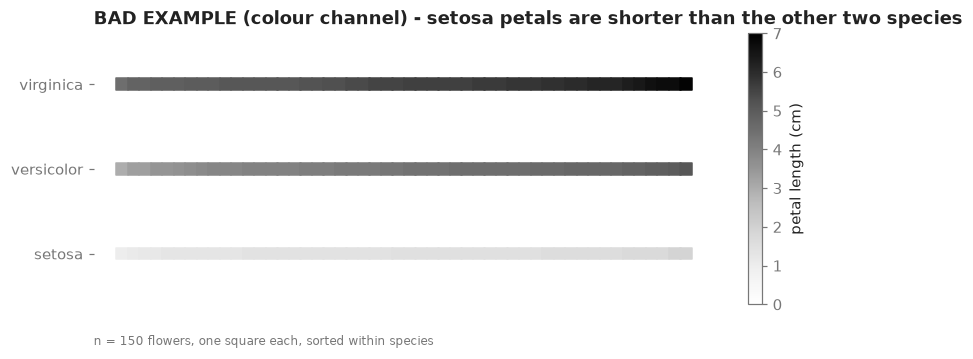

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for i, sp in enumerate(species):
    v = iris.loc[iris["species"] == sp, "petal_length"].sort_values().to_numpy()
    tiles = ax.scatter(np.arange(len(v)), np.full(len(v), i), c=v, cmap="Greys",
                       vmin=0, vmax=7, marker="s", s=60)
ax.set_yticks(range(3))
ax.set_yticklabels(species)
ax.set_xticks([])
ax.set_ylim(-0.6, 2.6)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(tiles, ax=ax, fraction=0.04)
cb.set_label("petal length (cm)")
ax.set_title("BAD EXAMPLE (colour channel) - setosa petals are shorter than the other two species")
ax.text(0, -0.15, "n = 150 flowers, one square each, sorted within species", transform=ax.transAxes,
        fontsize=8, color=GREY_DARK)
save(fig, "task4_iris_colour_bad")
plt.show()

Same data, same message. In B you can see that setosa is lighter, so the direction survives. But try to say *how much* shorter: you have to compare shades against the colour bar, and I can't tell 4.3 from 5.6 by greyness with any confidence. Lightness is also affected by what's around it (the same grey looks darker next to white).

In A the answer is a distance along one shared axis. You can read "about 1.5 vs about 4-5.5" straight off, and the overlap between versicolor and virginica is visible too, which B hides completely.

I'd publish A. Not because it looks nicer, but because position is the channel people decode most accurately for a quantity, so the reader gets the size of the difference right, not just its direction.

## The question: what can 30 data points from one reader support?

Very little statistically. Each channel has 6 trials from one person, so one bad guess moves a channel's mean a lot, and the error bars overlap. It can show that this particular reader, on this day, was clearly better with some channels than others. It can't support a general ranking, a claim about people in general, or a fine ordering between channels that are close (like position vs length, or angle vs area). There's also learning and fatigue within the session, and the screen and the size of the drawings matter.

The published ranking is still worth following because it comes from controlled experiments with many people and many trials (Cleveland & McGill, plus later replications like Heer & Bostock using crowdsourcing). They found the same order again and again. My small sample disagreeing with it would most likely be noise, not evidence against it. My result is useful as a demonstration that the channels feel different, not as a test of the theory.